In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("dataset.csv")
df.head(10)

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.info())
print(df.describe())

(4920, 18)
Index(['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
       'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9',
       'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14',
       'Symptom_15', 'Symptom_16', 'Symptom_17'],
      dtype='object')
Disease       object
Symptom_1     object
Symptom_2     object
Symptom_3     object
Symptom_4     object
Symptom_5     object
Symptom_6     object
Symptom_7     object
Symptom_8     object
Symptom_9     object
Symptom_10    object
Symptom_11    object
Symptom_12    object
Symptom_13    object
Symptom_14    object
Symptom_15    object
Symptom_16    object
Symptom_17    object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object

In [4]:
df.isnull().sum()

Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(4616)

In [6]:
df.iloc[:,0].value_counts()

Disease
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Psoriasis                                  120
Hepatitis D                                120
Hepatitis B                                120
Aller

In [7]:
symptom_columns=df.columns[1:]
unique_symptoms=pd.unique(df[symptom_columns].values.ravel())
unique_symptoms=pd.Series(unique_symptoms).dropna()
print("Number of unique symptoms:", unique_symptoms.nunique())
print(len(unique_symptoms))
print(unique_symptoms.tolist())

Number of unique symptoms: 131
131
['itching', ' skin_rash', ' nodal_skin_eruptions', ' dischromic _patches', ' continuous_sneezing', ' shivering', ' chills', ' watering_from_eyes', ' stomach_pain', ' acidity', ' ulcers_on_tongue', ' vomiting', ' cough', ' chest_pain', ' yellowish_skin', ' nausea', ' loss_of_appetite', ' abdominal_pain', ' yellowing_of_eyes', ' burning_micturition', ' spotting_ urination', ' passage_of_gases', ' internal_itching', ' indigestion', ' muscle_wasting', ' patches_in_throat', ' high_fever', ' extra_marital_contacts', ' fatigue', ' weight_loss', ' restlessness', ' lethargy', ' irregular_sugar_level', ' blurred_and_distorted_vision', ' obesity', ' excessive_hunger', ' increased_appetite', ' polyuria', ' sunken_eyes', ' dehydration', ' diarrhoea', ' breathlessness', ' family_history', ' mucoid_sputum', ' headache', ' dizziness', ' loss_of_balance', ' lack_of_concentration', ' stiff_neck', ' depression', ' irritability', ' visual_disturbances', ' back_pain', ' w

In [8]:
symptoms_with_spaces = [
    symptom for symptom in unique_symptoms
    if symptom != symptom.strip()
]
print("Symptoms with leading/trailing spaces:", len(symptoms_with_spaces))
print(symptoms_with_spaces)



symptoms_with_internal_spaces = [
    symptom for symptom in unique_symptoms
    if " " in symptom.strip()
]
print("Symptoms containing spaces:", len(symptoms_with_internal_spaces))
print(symptoms_with_internal_spaces)

Symptoms with leading/trailing spaces: 130
[' skin_rash', ' nodal_skin_eruptions', ' dischromic _patches', ' continuous_sneezing', ' shivering', ' chills', ' watering_from_eyes', ' stomach_pain', ' acidity', ' ulcers_on_tongue', ' vomiting', ' cough', ' chest_pain', ' yellowish_skin', ' nausea', ' loss_of_appetite', ' abdominal_pain', ' yellowing_of_eyes', ' burning_micturition', ' spotting_ urination', ' passage_of_gases', ' internal_itching', ' indigestion', ' muscle_wasting', ' patches_in_throat', ' high_fever', ' extra_marital_contacts', ' fatigue', ' weight_loss', ' restlessness', ' lethargy', ' irregular_sugar_level', ' blurred_and_distorted_vision', ' obesity', ' excessive_hunger', ' increased_appetite', ' polyuria', ' sunken_eyes', ' dehydration', ' diarrhoea', ' breathlessness', ' family_history', ' mucoid_sputum', ' headache', ' dizziness', ' loss_of_balance', ' lack_of_concentration', ' stiff_neck', ' depression', ' irritability', ' visual_disturbances', ' back_pain', ' weak

In [9]:
for symptom in symptoms_with_internal_spaces:
    print("\n", symptom)
    print(df[df.isin([symptom]).any(axis=1)].iloc[:, :5])


  dischromic _patches
               Disease   Symptom_1              Symptom_2  \
0     Fungal infection     itching              skin_rash   
1     Fungal infection   skin_rash   nodal_skin_eruptions   
2     Fungal infection     itching   nodal_skin_eruptions   
3     Fungal infection     itching              skin_rash   
5     Fungal infection   skin_rash   nodal_skin_eruptions   
...                ...         ...                    ...   
4715  Fungal infection     itching              skin_rash   
4756  Fungal infection     itching              skin_rash   
4797  Fungal infection     itching              skin_rash   
4838  Fungal infection     itching              skin_rash   
4879  Fungal infection     itching              skin_rash   

                  Symptom_3             Symptom_4  
0      nodal_skin_eruptions   dischromic _patches  
1       dischromic _patches                   NaN  
2       dischromic _patches                   NaN  
3       dischromic _patches         

In [10]:
clean_df=df.copy()
symptom_columns=clean_df.columns[1:]
for col in symptom_columns:
    clean_df[col]=clean_df[col].str.strip()
    clean_df[col] = clean_df[col].replace({
        "dischromic _patches": "dischromic_patches",
        "spotting_ urination": "spotting_urination",
        "foul_smell_of urine": "foul_smell_of_urine"
    })

In [11]:
clean_symptoms = clean_df.iloc[:, 1:].stack().unique()

print("Number of unique symptoms:", len(clean_symptoms))
print(sorted(clean_symptoms))

Number of unique symptoms: 131
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills', 'cold_hands_and_feets', 'coma', 'congestion', 'constipation', 'continuous_feel_of_urine', 'continuous_sneezing', 'cough', 'cramps', 'dark_urine', 'dehydration', 'depression', 'diarrhoea', 'dischromic_patches', 'distention_of_abdomen', 'dizziness', 'drying_and_tingling_lips', 'enlarged_thyroid', 'excessive_hunger', 'extra_marital_contacts', 'family_history', 'fast_heart_rate', 'fatigue', 'fluid_overload', 'foul_smell_of_urine', 'headache', 'high_fever', 'hip_joint_pain', 'history_of_alcohol_consumption', 'increased_appetite', 'indigestion', 'inflammatory_nails', 'internal_itching', 'irregular_sugar_level', 'irritabili

In [12]:
for symptom in clean_symptoms:
    if symptom != symptom.strip():
        print("Still has extra spaces:", repr(symptom))

In [13]:
ml_df=pd.DataFrame(0,index=clean_df.index,columns=clean_symptoms)
ml_df

,itching,skin_rash,nodal_skin_eruptions,dischromic_patches,continuous_sneezing,shivering,chills,watering_from_eyes,stomach_pain,acidity,...,bladder_discomfort,foul_smell_of_urine,continuous_feel_of_urine,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4916,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4917,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4918,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
for index, row in clean_df[symptom_columns].iterrows():
    for symptom in row.dropna():
        ml_df.loc[index, symptom] = 1
ml_df["Disease"] = clean_df["Disease"]
ml_df.head(15)

,itching,skin_rash,nodal_skin_eruptions,dischromic_patches,continuous_sneezing,shivering,chills,watering_from_eyes,stomach_pain,acidity,...,foul_smell_of_urine,continuous_feel_of_urine,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Disease
0,1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
5,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
6,1,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
7,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
8,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
9,1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [15]:
print("Shape:", ml_df.shape)

print("\nMissing values:")
print(ml_df.isnull().sum().sum())

print("\nSymptom values:")
print(ml_df.iloc[:, :-1].stack().unique())

print("\nDuplicates:")
print(ml_df.duplicated().sum())

Shape: (4920, 132)

Missing values:
0

Symptom values:
[1 0]

Duplicates:
4616


In [16]:
unique_df = ml_df.drop_duplicates().reset_index(drop=True)

print("Original rows:", len(ml_df))
print("Unique rows:", len(unique_df))
symptom_cols = unique_df.columns[:-1]
print(symptom_cols)
combination_counts = (
    unique_df.groupby(list(symptom_cols))["Disease"]
    .nunique()
)

print("Total unique symptom combinations:", len(combination_counts))
print(
    "Combinations associated with multiple diseases:",
    (combination_counts > 1).sum()
)
unique_df["Disease"].value_counts().sort_index()



# "The source dataset contained 4,920 records. After standardizing symptom representations and removing exact duplicate symptom-disease combinations, 304 unique patterns remained across 41 diseases and 131 symptoms."

Original rows: 4920
Unique rows: 304
Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'dischromic_patches',
       'continuous_sneezing', 'shivering', 'chills', 'watering_from_eyes',
       'stomach_pain', 'acidity',
       ...
       'bladder_discomfort', 'foul_smell_of_urine', 'continuous_feel_of_urine',
       'skin_peeling', 'silver_like_dusting', 'small_dents_in_nails',
       'inflammatory_nails', 'blister', 'red_sore_around_nose',
       'yellow_crust_ooze'],
      dtype='object', length=131)
Total unique symptom combinations: 304
Combinations associated with multiple diseases: 0


Disease
(vertigo) Paroymsal  Positional Vertigo     7
AIDS                                        5
Acne                                        5
Alcoholic hepatitis                         8
Allergy                                     5
Arthritis                                   6
Bronchial Asthma                            7
Cervical spondylosis                        6
Chicken pox                                10
Chronic cholestasis                         8
Common Cold                                 9
Dengue                                     10
Diabetes                                    9
Dimorphic hemmorhoids(piles)                6
Drug Reaction                               6
Fungal infection                            5
GERD                                        7
Gastroenteritis                             5
Heart attack                                5
Hepatitis B                                 9
Hepatitis C                                 7
Hepatitis D               

# SympScan dataset

In [17]:
df = pd.read_csv("Diseases_and_Symptoms_dataset.csv")

In [18]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [19]:
df.shape
df.columns
df.dtypes
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96088 entries, 0 to 96087
Columns: 231 entries, diseases to low urine output
dtypes: int64(230), object(1)
memory usage: 169.3+ MB


,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
count,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,...,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000
mean,0.028994,0.029900,0.097588,0.041087,0.098285,0.062661,0.035270,0.041389,0.045510,0.028120,...,0.010886,0.015486,0.004433,0.004184,0.004215,0.010355,0.004433,0.006223,0.004267,0.006296
std,0.167791,0.170311,0.296758,0.198493,0.297701,0.242354,0.184462,0.199190,0.208422,0.165317,...,0.103766,0.123475,0.066437,0.064546,0.064786,0.101232,0.066437,0.078643,0.065183,0.079100
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
df.isnull().sum()
df.isnull().sum().sum()

np.int64(0)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["diseases"].nunique()

100

In [23]:
df["diseases"].value_counts()

diseases
cystitis                              1219
nose disorder                         1218
vulvodynia                            1218
complex regional pain syndrome        1217
spondylosis                           1216
                                      ... 
pelvic inflammatory disease            804
gum disease                            803
temporary or benign blood in urine     803
allergy                                803
injury to the trunk                    803
Name: count, Length: 100, dtype: int64

In [24]:
df.iloc[:, 1:].stack().unique()

array([1, 0])

In [25]:
df.iloc[:, 1:].stack().value_counts()

0    21535947
1      564293
Name: count, dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.drop_duplicates().shape

(96088, 231)

In [28]:
symptom_columns = df.columns[1:]

pattern_disease_count = (
    df.groupby(list(symptom_columns), sort=False)["diseases"]
      .nunique()
)

print("Total unique symptom patterns:", len(pattern_disease_count))

print(
    "Patterns associated with multiple diseases:",
    (pattern_disease_count > 1).sum()
)

Total unique symptom patterns: 91210
Patterns associated with multiple diseases: 4046


In [29]:
multi_disease_patterns = pattern_disease_count[
    pattern_disease_count > 1
]

print(multi_disease_patterns.head(10))

anxiety and nervousness  depression  shortness of breath  depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  abnormal involuntary movements  chest tightness  palpitations  irregular heartbeat  breathing fast  hoarse voice  sore throat  difficulty speaking  cough  nasal congestion  throat swelling  diminished hearing  difficulty in swallowing  skin swelling  retention of urine  leg pain  hip pain  suprapubic pain  blood in stool  lack of growth  symptoms of the scrotum and testes  swelling of scrotum  pain in testicles  pus draining from ear  jaundice  white discharge from eye  irritable infant  abusing alcohol  fainting  hostile behavior  drug abuse  sharp abdominal pain  feeling ill  vomiting  headache  nausea  diarrhea  vaginal itching  painful urination  involuntary urination  pain during intercourse  frequent urination  lower abdominal pain  vaginal discharge  blood in urine  hot flashes  intermenstrual bleeding  hand or finger pain  wrist pain  hand or finger

In [30]:
for pattern in multi_disease_patterns.index[:5]:
    matching_rows = df[
        (df[symptom_columns] == pattern).all(axis=1)
    ]
    
    print("Diseases:", matching_rows["diseases"].unique())
    print()

Diseases: ['panic disorder' 'marijuana abuse' 'anxiety' 'depression'
 'personality disorder']

Diseases: ['panic disorder' 'anxiety']

Diseases: ['panic disorder' 'anxiety']

Diseases: ['panic disorder' 'marijuana abuse' 'depression' 'personality disorder']

Diseases: ['panic disorder' 'anxiety']



In [31]:
print("Original rows:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())

Original rows: 96088
Exact duplicate rows: 0


In [32]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Rows involved in duplicates:", len(duplicate_rows))

Rows involved in duplicates: 0


In [33]:
symptom_counts = df[symptom_columns].sum()

print("Symptoms that never occur:")
print(symptom_counts[symptom_counts == 0])
print("Symptoms that occur in every row:")
print(symptom_counts[symptom_counts == len(df)])

Symptoms that never occur:
Series([], dtype: int64)
Symptoms that occur in every row:
Series([], dtype: int64)


In [34]:
X = df.drop("diseases", axis=1)

print(X.shape)

y = df["diseases"]

print(y.shape)
print(y.head())

(96088, 230)
(96088,)
0    panic disorder
1    panic disorder
2    panic disorder
3    panic disorder
4    panic disorder
Name: diseases, dtype: object


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (76870, 230)
X_test: (19218, 230)
y_train: (76870,)
y_test: (19218,)


In [36]:
print("Training diseases:", y_train.nunique())
print("Testing diseases:", y_test.nunique())

Training diseases: 100
Testing diseases: 100


In [37]:
print("Training distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting distribution:")
print(y_test.value_counts().sort_index())

Training distribution:
diseases
actinic keratosis          646
acute bronchiolitis        963
acute bronchitis           970
acute bronchospasm         650
acute kidney injury        646
                          ... 
threatened pregnancy       654
urinary tract infection    652
vaginal cyst               972
vaginitis                  657
vulvodynia                 974
Name: count, Length: 100, dtype: int64

Testing distribution:
diseases
actinic keratosis          162
acute bronchiolitis        241
acute bronchitis           243
acute bronchospasm         162
acute kidney injury        162
                          ... 
threatened pregnancy       164
urinary tract infection    163
vaginal cyst               243
vaginitis                  164
vulvodynia                 244
Name: count, Length: 100, dtype: int64


In [38]:
train_patterns = X_train.drop_duplicates()
test_patterns = X_test.drop_duplicates()

print("Unique patterns in training:", len(train_patterns))
print("Unique patterns in testing:", len(test_patterns))

Unique patterns in training: 73505
Unique patterns in testing: 19028


In [39]:
train_pattern_set = set(map(tuple, X_train.values))

test_pattern_overlap = sum(
    tuple(row) in train_pattern_set
    for row in X_test.values
)

print("Test patterns also found in training:", test_pattern_overlap)
print("Total test rows:", len(X_test))

Test patterns also found in training: 1394
Total test rows: 19218


In [40]:
train_df = X_train.copy()
train_df["disease"] = y_train.values

test_df = X_test.copy()
test_df["disease"] = y_test.values

overlap_check = test_df.merge(
    train_df.drop_duplicates(),
    on=list(X_train.columns),
    how="inner"
)

print("Overlapping rows:", len(overlap_check))

Overlapping rows: 1825


In [41]:
disease_columns = ["disease_x", "disease_y"]

different_disease = (
    overlap_check["disease_x"] != overlap_check["disease_y"]
)

print(
    "Overlapping patterns with different diseases:",
    different_disease.sum()
)

Overlapping patterns with different diseases: 1825


In [42]:
pattern_disease_count.value_counts().sort_index()

diseases
1     87164
2      3427
3       482
4        93
5        28
6        10
7         2
8         1
9         2
12        1
Name: count, dtype: int64

In [43]:
overlap_examples = overlap_check[
    overlap_check["disease_x"] != overlap_check["disease_y"]
]

print(overlap_examples[["disease_x", "disease_y"]].head(20))

disease_pairs = (
    overlap_examples
    .groupby(["disease_x", "disease_y"])
    .size()
    .sort_values(ascending=False)
)

print(disease_pairs.head(20))

print("Total conflicting overlap rows:", len(overlap_examples))
print("Unique disease pairs:", len(disease_pairs))

                        disease_x  \
0                    otitis media   
1                 spinal stenosis   
2                        cystitis   
3                   liver disease   
4       peripheral nerve disorder   
5       peripheral nerve disorder   
6                       vaginitis   
7                          eczema   
8                      skin polyp   
9                        bursitis   
10                         asthma   
11                    spondylosis   
12                    spondylosis   
13                    spondylosis   
14  noninfectious gastroenteritis   
15  noninfectious gastroenteritis   
16                 diverticulitis   
17                         sepsis   
18                         sepsis   
19                         sepsis   

                                       disease_y  
0   chronic obstructive pulmonary disease (copd)  
1                      degenerative disc disease  
2                        urinary tract infection  
3                 

In [44]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Number of classes:", len(label_encoder.classes_))
print("First 10 classes:")
print(label_encoder.classes_[:10])

Number of classes: 100
First 10 classes:
['actinic keratosis' 'acute bronchiolitis' 'acute bronchitis'
 'acute bronchospasm' 'acute kidney injury' 'acute pancreatitis'
 'acute sinusitis' 'allergy' 'angina' 'anxiety']


In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train_encoded)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 7 61 50 24 88 13 15 44 64 99]


In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8985326256634405


In [48]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

                                              precision    recall  f1-score   support

                           actinic keratosis       0.93      0.72      0.81       162
                         acute bronchiolitis       0.95      0.92      0.93       241
                            acute bronchitis       0.87      0.76      0.81       243
                          acute bronchospasm       0.66      0.78      0.71       162
                         acute kidney injury       0.98      0.99      0.98       162
                          acute pancreatitis       0.93      0.85      0.89       241
                             acute sinusitis       0.85      0.92      0.88       166
                                     allergy       0.94      0.98      0.96       161
                                      angina       0.95      0.98      0.96       165
                                     anxiety       0.97      0.97      0.97       240
                                appendicitis       0.

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

print(cm.shape)

(100, 100)


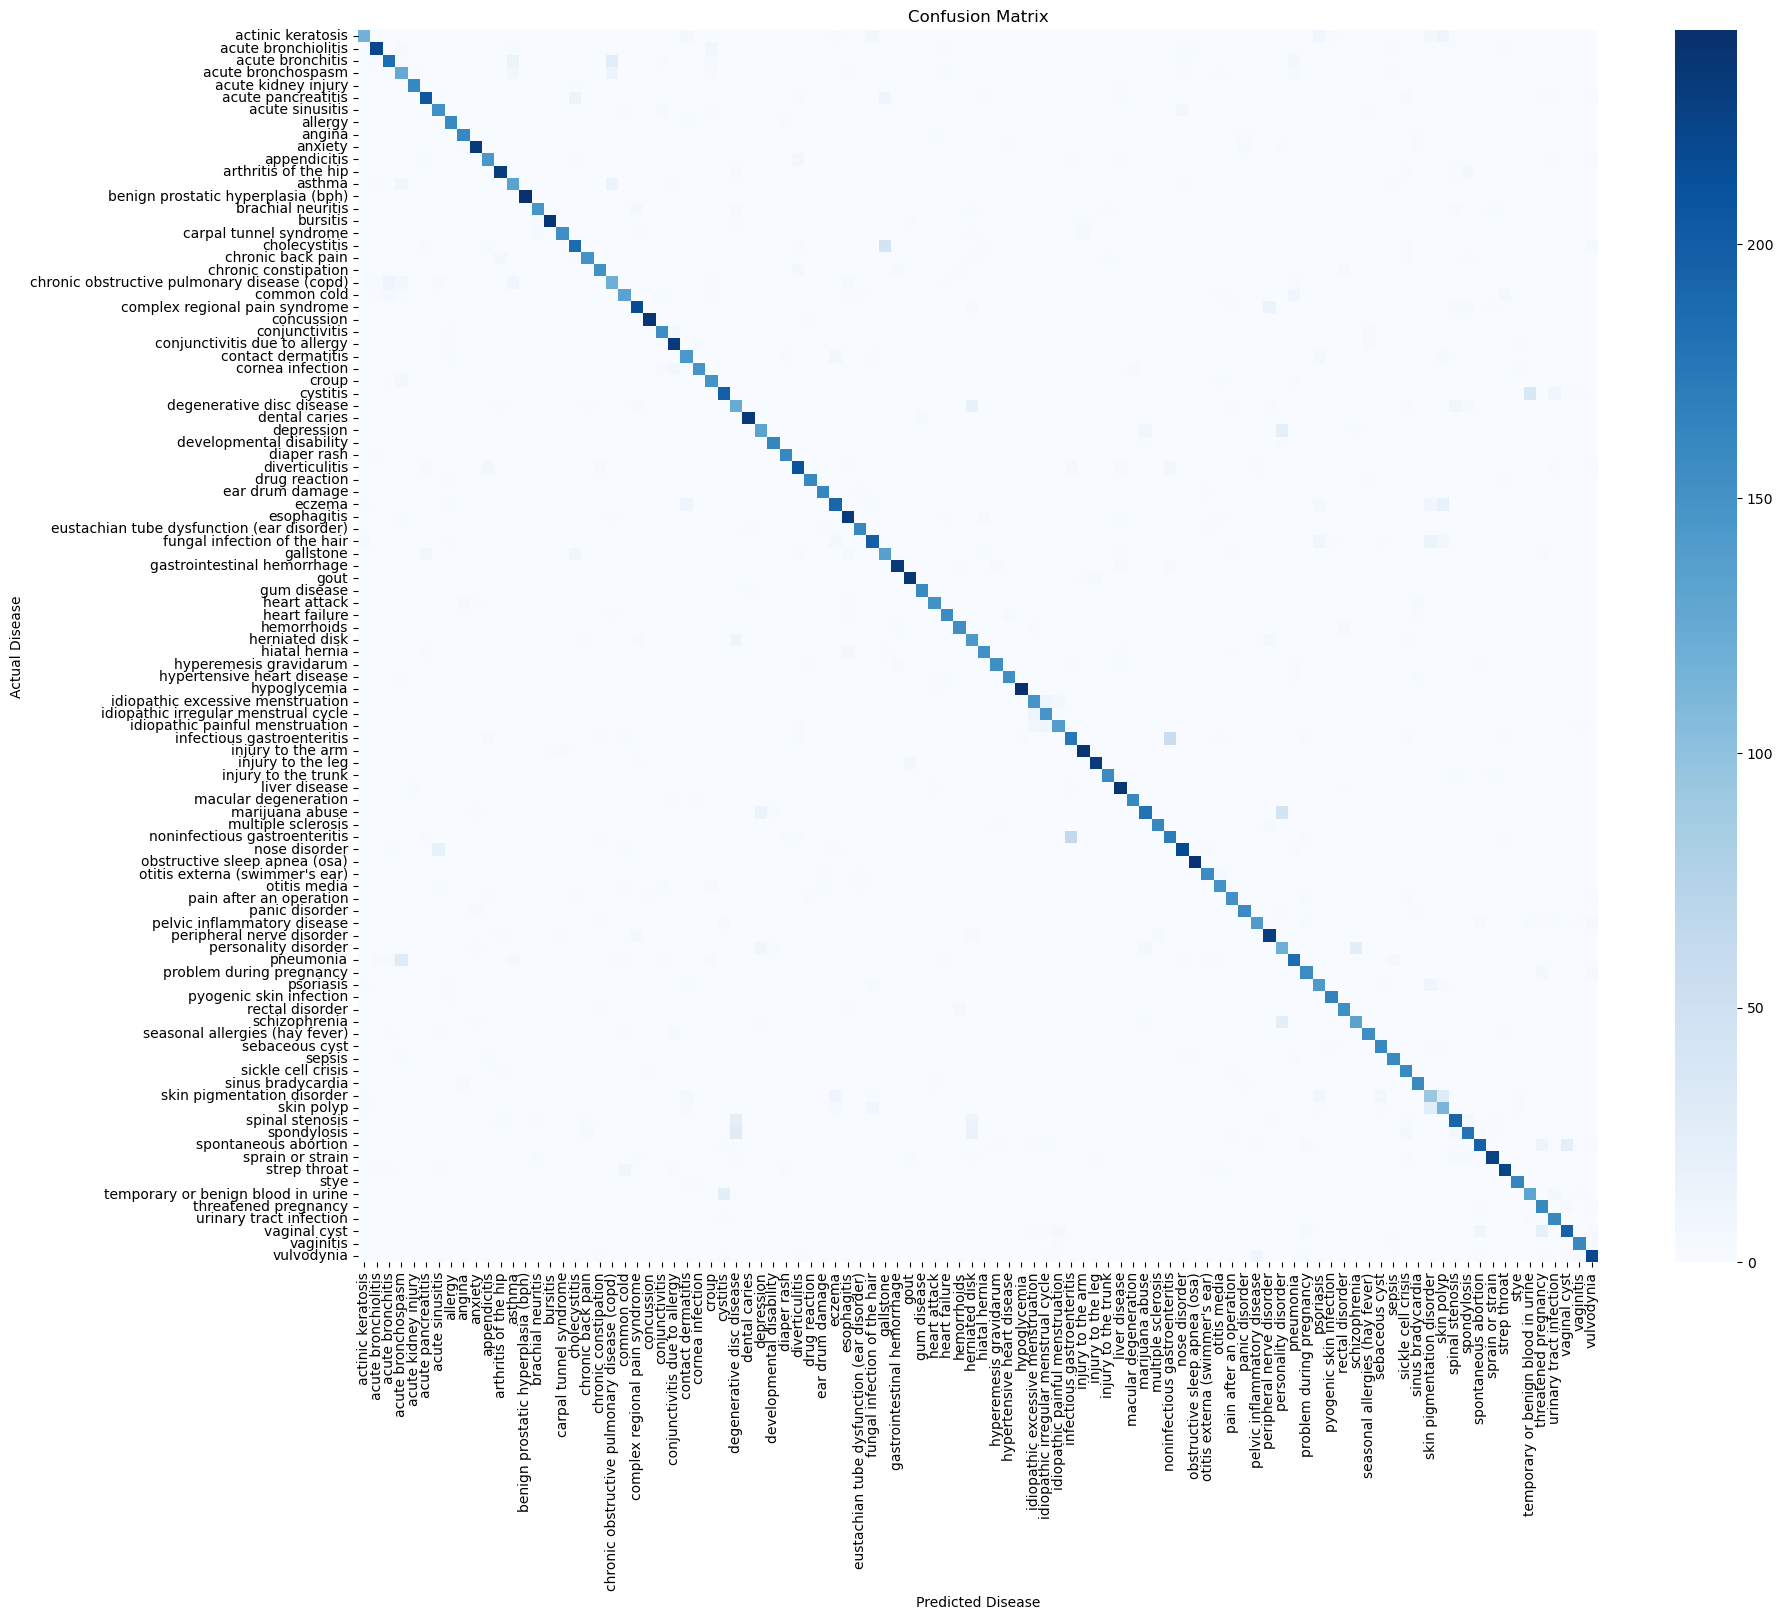

In [50]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Confusion Matrix")

plt.show()

In [51]:
cm_without_diagonal = cm.copy()

np.fill_diagonal(cm_without_diagonal, 0)

top_confusions = []

for i in range(len(cm_without_diagonal)):
    for j in range(len(cm_without_diagonal)):
        if cm_without_diagonal[i, j] > 0:
            top_confusions.append((
                cm_without_diagonal[i, j],
                label_encoder.classes_[i],
                label_encoder.classes_[j]
            ))

top_confusions = sorted(top_confusions, reverse=True)

top_confusions[:20]

[(np.int64(63), 'noninfectious gastroenteritis', 'infectious gastroenteritis'),
 (np.int64(54), 'infectious gastroenteritis', 'noninfectious gastroenteritis'),
 (np.int64(44), 'marijuana abuse', 'personality disorder'),
 (np.int64(44), 'cholecystitis', 'gallstone'),
 (np.int64(37), 'cystitis', 'temporary or benign blood in urine'),
 (np.int64(30), 'skin pigmentation disorder', 'skin polyp'),
 (np.int64(29), 'spondylosis', 'degenerative disc disease'),
 (np.int64(29), 'pneumonia', 'acute bronchospasm'),
 (np.int64(27), 'skin polyp', 'skin pigmentation disorder'),
 (np.int64(27),
  'acute bronchitis',
  'chronic obstructive pulmonary disease (copd)'),
 (np.int64(25), 'personality disorder', 'schizophrenia'),
 (np.int64(24), 'temporary or benign blood in urine', 'cystitis'),
 (np.int64(24), 'schizophrenia', 'personality disorder'),
 (np.int64(23), 'spontaneous abortion', 'vaginal cyst'),
 (np.int64(23), 'depression', 'personality disorder'),
 (np.int64(22), 'spinal stenosis', 'degenerativ

In [52]:
y_test_reset = y_test.reset_index(drop=True)
y_test_encoded = label_encoder.transform(y_test)

In [53]:
y_proba = model.predict_proba(X_test)

top3_indices = np.argsort(y_proba, axis=1)[:, -3:]

top3_accuracy = np.mean([
    y_test_encoded.iloc[i] if hasattr(y_test_encoded, "iloc") else y_test_encoded[i]
    in top3_indices[i]
    for i in range(len(y_test_encoded))
])

print("Top-3 Accuracy:", top3_accuracy)

Top-3 Accuracy: 0.9847538765740451


In [54]:
top5_indices = np.argsort(y_proba, axis=1)[:, -5:]

top5_accuracy = np.mean([
    y_test_encoded.iloc[i] if hasattr(y_test_encoded, "iloc") else y_test_encoded[i]
    in top5_indices[i]
    for i in range(len(y_test_encoded))
])

print("Top-5 Accuracy:", top5_accuracy)

Top-5 Accuracy: 0.9963055468831304


In [55]:
import joblib

joblib.dump(model, "disease_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model and label encoder saved successfully!")

Model and label encoder saved successfully!


In [56]:
symptom_columns = df.columns[1:]

joblib.dump(symptom_columns.tolist(), "symptom_columns.pkl")

print("Symptom columns saved:", len(symptom_columns))

Symptom columns saved: 230


In [60]:
def predict_top_diseases(symptoms, top_n=5):
    
    # 230 symptoms ke liye 0 se start
    input_data = np.zeros(len(symptom_columns), dtype=int)
    
    # User ke symptoms ko 1 karo
    for symptom in symptoms:
        if symptom in symptom_columns:
            index = list(symptom_columns).index(symptom)
            input_data[index] = 1
    
    # DataFrame with same feature names
    input_df = pd.DataFrame(
        [input_data],
        columns=symptom_columns
    )
    
    # Probability of every disease
    probabilities = model.predict_proba(input_df)[0]
    
    # Highest probabilities ke indices
    top_indices = np.argsort(probabilities)[-top_n:][::-1]
    
    results = []
    
    for index in top_indices:
        
        disease = label_encoder.inverse_transform([index])[0]
        probability = probabilities[index]
        
        results.append(
            (disease, probability)
        )
    
    return results




test_symptoms = [
    "anxiety and nervousness",
    "depression",
    "insomnia"
]

results = predict_top_diseases(test_symptoms)

for rank, (disease, probability) in enumerate(results, start=1):
    print(f"{rank}. {disease} - {probability:.2%}")

1. schizophrenia - 30.91%
2. panic disorder - 20.92%
3. personality disorder - 19.12%
4. depression - 13.73%
5. anxiety - 13.38%


In [61]:
description_df = pd.read_csv("description.csv")

description_df.head()

,Disease,Description
0,Panic disorder,Panic disorder is a mental health condition ma...
1,Vaginitis,Vaginitis is inflammation of the vaginal tissu...
2,Problem during pregnancy,Problems during pregnancy refer to medical com...
3,Acute pancreatitis,Acute pancreatitis is a sudden inflammation of...
4,Asthma,Asthma is a chronic inflammatory disease of th...


In [62]:
print("Shape:", description_df.shape)

print("\nColumns:")
print(description_df.columns)

print("\nData types:")
print(description_df.dtypes)

print("\nMissing values:")
print(description_df.isnull().sum())

print("\nNumber of diseases:")
print(description_df.iloc[:, 0].nunique())

Shape: (100, 2)

Columns:
Index(['Disease', 'Description'], dtype='object')

Data types:
Disease        object
Description    object
dtype: object

Missing values:
Disease        0
Description    0
dtype: int64

Number of diseases:
100


In [63]:
model_diseases = set(label_encoder.classes_)

description_diseases = set(description_df["Disease"].str.strip().str.lower())

model_diseases = set(
    disease.strip().lower()
    for disease in model_diseases
)

print("Diseases in model:", len(model_diseases))
print("Diseases in description:", len(description_diseases))

print("\nModel diseases missing in description:")
print(model_diseases - description_diseases)

print("\nDescription diseases missing in model:")
print(description_diseases - model_diseases)

Diseases in model: 100
Diseases in description: 100

Model diseases missing in description:
set()

Description diseases missing in model:
set()


In [65]:
description_df["Disease"] = (
    description_df["Disease"]
    .str.strip()
    .str.lower()
)

description_lookup = dict(
    zip(
        description_df["Disease"],
        description_df["Description"]
    )
)

print("Descriptions available:", len(description_lookup))
description_lookup["asthma"]

Descriptions available: 100


'Asthma is a chronic inflammatory disease of the airways causing recurrent wheezing, breathlessness, chest tightness, and coughing, often triggered by allergens, exercise, or cold air.'

In [66]:
def predict_top_diseases_with_description(symptoms, top_n=5):
    
    input_data = np.zeros(len(symptom_columns), dtype=int)
    
    for symptom in symptoms:
        if symptom in symptom_columns:
            index = list(symptom_columns).index(symptom)
            input_data[index] = 1
    
    input_df = pd.DataFrame(
        [input_data],
        columns=symptom_columns
    )
    
    probabilities = model.predict_proba(input_df)[0]
    
    top_indices = np.argsort(probabilities)[-top_n:][::-1]
    
    results = []
    
    for index in top_indices:
        
        disease = label_encoder.inverse_transform([index])[0]
        disease_key = disease.strip().lower()
        
        probability = probabilities[index]
        description = description_lookup[disease_key]
        
        results.append({
            "Disease": disease,
            "Probability": probability,
            "Description": description
        })
    
    return results




test_symptoms = [
    "anxiety and nervousness",
    "depression",
    "insomnia"
]

results = predict_top_diseases_with_description(test_symptoms)

for i, result in enumerate(results, start=1):
    print(f"\n{i}. {result['Disease']}")
    print(f"Probability: {result['Probability']:.2%}")
    print(f"Description: {result['Description']}")


1. schizophrenia
Probability: 30.91%
Description: Schizophrenia is a severe psychiatric disorder involving distortions in thinking, perception, emotions, language, and behavior, often with hallucinations or delusions.

2. panic disorder
Probability: 20.92%
Description: Panic disorder is a mental health condition marked by sudden, unexpected panic attacks—intense periods of fear or discomfort—often accompanied by physical symptoms like chest pain, rapid heartbeat, shortness of breath, or dizziness.

3. personality disorder
Probability: 19.12%
Description: Personality disorders are mental health conditions involving rigid and unhealthy patterns of thinking, functioning, and behaving that impair social or occupational life.

4. depression
Probability: 13.73%
Description: Depression is a mental health disorder characterized by persistent sadness, loss of interest or pleasure, fatigue, and changes in sleep or appetite, significantly impacting daily life.

5. anxiety
Probability: 13.38%
Des

In [67]:
precautions_df = pd.read_csv("precautions.csv")

precautions_df.head()

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Panic disorder,Practice deep breathing,Avoid caffeine,Follow therapy plan,Seek support from loved ones
1,Vaginitis,Wear breathable cotton underwear,Avoid douching,Maintain genital hygiene,Avoid scented hygiene products
2,Problem during pregnancy,Attend regular prenatal visits,Avoid alcohol and smoking,Eat a balanced diet,Get adequate rest
3,Acute pancreatitis,Avoid alcohol,Eat a low-fat diet,Stay hydrated,Follow doctor's advice strictly
4,Asthma,Avoid known triggers,Use inhaler as prescribed,Monitor peak flow,Keep emergency inhaler handy


In [68]:
print("Shape:", precautions_df.shape)

print("\nColumns:")
print(precautions_df.columns)

print("\nData types:")
print(precautions_df.dtypes)

print("\nMissing values:")
print(precautions_df.isnull().sum())

print("\nNumber of diseases:")
print(precautions_df.iloc[:, 0].nunique())

Shape: (100, 5)

Columns:
Index(['Disease', 'Precaution_1', 'Precaution_2', 'Precaution_3',
       'Precaution_4'],
      dtype='object')

Data types:
Disease         object
Precaution_1    object
Precaution_2    object
Precaution_3    object
Precaution_4    object
dtype: object

Missing values:
Disease         0
Precaution_1    0
Precaution_2    0
Precaution_3    0
Precaution_4    0
dtype: int64

Number of diseases:
100


In [71]:
precaution_diseases = set(
    precautions_df["Disease"]
    .str.strip()
    .str.lower()
)

print("Diseases in model:", len(model_diseases))
print("Diseases in precautions:", len(precaution_diseases))

print("\nModel diseases missing in precautions:")
print(model_diseases - precaution_diseases)

print("\nPrecaution diseases missing in model:")
print(precaution_diseases - model_diseases)

Diseases in model: 100
Diseases in precautions: 100

Model diseases missing in precautions:
set()

Precaution diseases missing in model:
set()


In [70]:
precautions_df["Disease"] = (
    precautions_df["Disease"]
    .str.strip()
    .str.lower()
)

precautions_df["Disease"] = precautions_df["Disease"].replace(
    {
        "copd": "chronic obstructive pulmonary disease (copd)"
    }
)

In [72]:
precaution_diseases = set(
    precautions_df["Disease"]
    .str.strip()
    .str.lower()
)

print("Diseases in model:", len(model_diseases))
print("Diseases in precautions:", len(precaution_diseases))

print("\nModel diseases missing in precautions:")
print(model_diseases - precaution_diseases)

print("\nPrecaution diseases missing in model:")
print(precaution_diseases - model_diseases)

Diseases in model: 100
Diseases in precautions: 100

Model diseases missing in precautions:
set()

Precaution diseases missing in model:
set()


In [73]:
precaution_lookup = (
    precautions_df
    .set_index("Disease")
    [["Precaution_1", "Precaution_2", "Precaution_3", "Precaution_4"]]
    .to_dict("index")
)

print("Precaution records available:", len(precaution_lookup))

print(precaution_lookup["asthma"])

Precaution records available: 100
{'Precaution_1': 'Avoid known triggers', 'Precaution_2': 'Use inhaler as prescribed', 'Precaution_3': 'Monitor peak flow', 'Precaution_4': 'Keep emergency inhaler handy'}


In [74]:
def predict_diseases_with_info(symptoms, top_n=5):
    
    # 230 symptoms ke liye 0 se start
    input_data = np.zeros(len(symptom_columns), dtype=int)
    
    # User ke symptoms ko 1 karo
    for symptom in symptoms:
        if symptom in symptom_columns:
            index = list(symptom_columns).index(symptom)
            input_data[index] = 1
    
    # Same feature names ke saath DataFrame
    input_df = pd.DataFrame(
        [input_data],
        columns=symptom_columns
    )
    
    # Har disease ki probability
    probabilities = model.predict_proba(input_df)[0]
    
    # Top diseases
    top_indices = np.argsort(probabilities)[-top_n:][::-1]
    
    results = []
    
    for index in top_indices:
        
        # Disease name
        disease = label_encoder.inverse_transform([index])[0]
        disease_key = disease.strip().lower()
        
        # Probability
        probability = probabilities[index]
        
        # Description
        description = description_lookup[disease_key]
        
        # Precautions
        precautions = precaution_lookup[disease_key]
        
        results.append({
            "Disease": disease,
            "Probability": probability,
            "Description": description,
            "Precautions": precautions
        })
    
    return results




test_symptoms = [
    "anxiety and nervousness",
    "depression",
    "insomnia"
]

results = predict_diseases_with_info(test_symptoms)

for i, result in enumerate(results, start=1):
    
    print(f"\n{i}. {result['Disease']}")
    print(f"Probability: {result['Probability']:.2%}")
    print(f"Description: {result['Description']}")
    
    print("Precautions:")
    
    for key, value in result["Precautions"].items():
        print(f"- {value}")


1. schizophrenia
Probability: 30.91%
Description: Schizophrenia is a severe psychiatric disorder involving distortions in thinking, perception, emotions, language, and behavior, often with hallucinations or delusions.
Precautions:
- Adhere to medication
- Avoid substance abuse
- Attend therapy sessions
- Build a support network

2. panic disorder
Probability: 20.92%
Description: Panic disorder is a mental health condition marked by sudden, unexpected panic attacks—intense periods of fear or discomfort—often accompanied by physical symptoms like chest pain, rapid heartbeat, shortness of breath, or dizziness.
Precautions:
- Practice deep breathing
- Avoid caffeine
- Follow therapy plan
- Seek support from loved ones

3. personality disorder
Probability: 19.12%
Description: Personality disorders are mental health conditions involving rigid and unhealthy patterns of thinking, functioning, and behaving that impair social or occupational life.
Precautions:
- Follow psychotherapy plan
- Avoi

In [75]:
diets_df = pd.read_csv("diets.csv")

diets_df.head()

,Disease,Diet
0,Panic Disorder,"['Magnesium-rich foods (spinach, pumpkin seeds..."
1,Vaginitis,"['Probiotics (yogurt, kefir, sauerkraut)', 'Lo..."
2,Problem During Pregnancy,"['Prenatal vitamins (consult doctor)', 'Iron-r..."
3,Acute Pancreatitis,"['Low-fat foods (boiled vegetables, lean chick..."
4,Asthma,"['Anti-inflammatory foods (blueberries, kale, ..."


In [76]:
print("Shape:", diets_df.shape)

print("\nColumns:")
print(diets_df.columns)

print("\nData types:")
print(diets_df.dtypes)

print("\nMissing values:")
print(diets_df.isnull().sum())

print("\nNumber of diseases:")
print(diets_df.iloc[:, 0].nunique())

Shape: (100, 2)

Columns:
Index(['Disease', 'Diet'], dtype='object')

Data types:
Disease    object
Diet       object
dtype: object

Missing values:
Disease    0
Diet       0
dtype: int64

Number of diseases:
100


In [77]:
diet_diseases = set(
    diets_df["Disease"]
    .str.strip()
    .str.lower()
)

print("Diseases in model:", len(model_diseases))
print("Diseases in diets:", len(diet_diseases))

print("\nModel diseases missing in diets:")
print(model_diseases - diet_diseases)

print("\nDiet diseases missing in model:")
print(diet_diseases - model_diseases)

Diseases in model: 100
Diseases in diets: 100

Model diseases missing in diets:
set()

Diet diseases missing in model:
set()


In [83]:
import ast
diet_lookup = {}

for _, row in diets_df.iterrows():
    
    disease = row["Disease"].strip().lower()
    
    diet = ast.literal_eval(row["Diet"])
    
    diet_lookup[disease] = diet

print("Diet records available:", len(diet_lookup))
print(diet_lookup["asthma"])

Diet records available: 100
['Anti-inflammatory foods (blueberries, kale, turmeric)', 'Magnesium-rich foods (pumpkin seeds, spinach)', 'Omega-3s (wild salmon, chia seeds)', 'Avoid dairy if sensitive', 'Vitamin D-rich foods (egg yolks, fortified milk)']


In [84]:
def predict_diseases_with_info(symptoms, top_n=5):
    
    # 230 symptoms ke liye 0 se start
    input_data = np.zeros(len(symptom_columns), dtype=int)
    
    # User ke symptoms ko 1 karo
    for symptom in symptoms:
        if symptom in symptom_columns:
            index = list(symptom_columns).index(symptom)
            input_data[index] = 1
    
    # DataFrame with feature names
    input_df = pd.DataFrame(
        [input_data],
        columns=symptom_columns
    )
    
    # Har disease ki probability
    probabilities = model.predict_proba(input_df)[0]
    
    # Top diseases
    top_indices = np.argsort(probabilities)[-top_n:][::-1]
    
    results = []
    
    for index in top_indices:
        
        disease = label_encoder.inverse_transform([index])[0]
        disease_key = disease.strip().lower()
        
        probability = probabilities[index]
        
        # Description
        description = description_lookup[disease_key]
        
        # Precautions
        precautions = precaution_lookup[disease_key]
        
        # Diet
        diet = diet_lookup[disease_key]
        
        results.append({
            "Disease": disease,
            "Probability": probability,
            "Description": description,
            "Precautions": precautions,
            "Diet": diet
        })
    
    return results






test_symptoms = [
    "anxiety and nervousness",
    "depression",
    "insomnia"
]

results = predict_diseases_with_info(test_symptoms)

for i, result in enumerate(results, start=1):
    
    print(f"\n{i}. {result['Disease']}")
    print(f"Probability: {result['Probability']:.2%}")
    
    print(f"Description: {result['Description']}")
    
    print("Precautions:")
    for key, value in result["Precautions"].items():
        print(f"- {value}")
    
    print("Diet:")
    for item in result["Diet"]:
        print(f"- {item}")


1. schizophrenia
Probability: 30.91%
Description: Schizophrenia is a severe psychiatric disorder involving distortions in thinking, perception, emotions, language, and behavior, often with hallucinations or delusions.
Precautions:
- Adhere to medication
- Avoid substance abuse
- Attend therapy sessions
- Build a support network
Diet:
- Omega-3 fatty acids (fish, flaxseeds)
- Complex carbs (whole grains, vegetables)
- Vitamin B-complex foods (eggs, nuts)
- Antioxidant-rich foods (berries, citrus)
- Limit caffeine and processed foods

2. panic disorder
Probability: 20.92%
Description: Panic disorder is a mental health condition marked by sudden, unexpected panic attacks—intense periods of fear or discomfort—often accompanied by physical symptoms like chest pain, rapid heartbeat, shortness of breath, or dizziness.
Precautions:
- Practice deep breathing
- Avoid caffeine
- Follow therapy plan
- Seek support from loved ones
Diet:
- Magnesium-rich foods (spinach, pumpkin seeds, almonds)
- Om

In [85]:
workout_df = pd.read_csv("workout.csv")

workout_df.head()

,Disease,Workouts
0,Panic disorder,"[""Deep breathing exercises: Calm your mind by ..."
1,Vaginitis,"[""Pelvic floor exercises: Strengthen pelvic mu..."
2,Problem during pregnancy,"[""Prenatal yoga: Gentle stretches safe for pre..."
3,Acute pancreatitis,"[""Avoid heavy lifting: Prevent strain on pancr..."
4,Asthma,"[""Breathing exercises: Improve lung function"",..."


In [86]:
print("Shape:", workout_df.shape)

print("\nColumns:")
print(workout_df.columns)

print("\nData types:")
print(workout_df.dtypes)

print("\nMissing values:")
print(workout_df.isnull().sum())

print("\nNumber of diseases:")
print(workout_df["Disease"].nunique())

Shape: (100, 2)

Columns:
Index(['Disease', 'Workouts'], dtype='object')

Data types:
Disease     object
Workouts    object
dtype: object

Missing values:
Disease     0
Workouts    0
dtype: int64

Number of diseases:
100


In [87]:
model_diseases = set(label_encoder.classes_)
workout_diseases = set(workout_df["Disease"].str.lower().str.strip())

print("Diseases in model:", len(model_diseases))
print("Diseases in workout:", len(workout_diseases))

print("\nModel diseases missing in workout:")
print(model_diseases - workout_diseases)

print("\nWorkout diseases missing in model:")
print(workout_diseases - model_diseases)

Diseases in model: 100
Diseases in workout: 100

Model diseases missing in workout:
set()

Workout diseases missing in model:
set()


In [89]:
import ast

workout_df["Disease"] = (
    workout_df["Disease"]
    .str.strip()
    .str.lower()
)

workout_lookup = {}

for _, row in workout_df.iterrows():
    
    disease = row["Disease"]
    workouts = ast.literal_eval(row["Workouts"])
    
    workout_lookup[disease] = workouts

print("Workout records available:", len(workout_lookup))
print(workout_lookup["asthma"])

Workout records available: 100
['Breathing exercises: Improve lung function', 'Yoga: Combines breathing and movement', 'Swimming: Low-impact cardio good for lungs', 'Avoid strenuous workouts during flare-ups: Prevent attacks']


In [90]:
def predict_diseases_with_info(symptoms, top_n=5):
    
    # -----------------------------------
    # 1. Create empty input
    # -----------------------------------
    
    input_data = np.zeros(len(symptom_columns), dtype=int)
    
    
    # -----------------------------------
    # 2. Set user's symptoms to 1
    # -----------------------------------
    
    for symptom in symptoms:
        
        if symptom in symptom_columns:
            index = list(symptom_columns).index(symptom)
            input_data[index] = 1
    
    
    # -----------------------------------
    # 3. Convert into DataFrame
    # -----------------------------------
    
    input_df = pd.DataFrame(
        [input_data],
        columns=symptom_columns
    )
    
    
    # -----------------------------------
    # 4. Get probabilities
    # -----------------------------------
    
    probabilities = model.predict_proba(input_df)[0]
    
    
    # -----------------------------------
    # 5. Get Top-N diseases
    # -----------------------------------
    
    top_indices = np.argsort(probabilities)[-top_n:][::-1]
    
    
    # -----------------------------------
    # 6. Store results
    # -----------------------------------
    
    results = []
    
    
    for index in top_indices:
        
        # Disease name
        disease = label_encoder.inverse_transform([index])[0]
        
        # Convert disease name into lookup format
        disease_key = disease.strip().lower()
        
        
        # Probability
        probability = probabilities[index]
        
        
        # -----------------------------------
        # 7. Get additional information
        # -----------------------------------
        
        description = description_lookup[disease_key]
        
        precautions = precaution_lookup[disease_key]
        
        diet = diet_lookup[disease_key]
        
        workouts = workout_lookup[disease_key]
        
        
        # -----------------------------------
        # 8. Store everything
        # -----------------------------------
        
        results.append({
            
            "Disease": disease,
            
            "Probability": probability,
            
            "Description": description,
            
            "Precautions": precautions,
            
            "Diet": diet,
            
            "Workouts": workouts
        })
    
    
    return results




test_symptoms = [
    "anxiety and nervousness",
    "depression",
    "insomnia"
]

results = predict_diseases_with_info(test_symptoms)




for i, result in enumerate(results, start=1):
    
    print(f"\n{i}. {result['Disease']}")
    
    print(f"Probability: {result['Probability']:.2%}")
    
    
    print("\nDescription:")
    print(result["Description"])
    
    
    print("\nPrecautions:")
    
    for value in result["Precautions"].values():
        print(f"- {value}")
    
    
    print("\nDiet:")
    
    for item in result["Diet"]:
        print(f"- {item}")
    
    
    print("\nWorkout:")
    
    for workout in result["Workouts"]:
        print(f"- {workout}")


1. schizophrenia
Probability: 30.91%

Description:
Schizophrenia is a severe psychiatric disorder involving distortions in thinking, perception, emotions, language, and behavior, often with hallucinations or delusions.

Precautions:
- Adhere to medication
- Avoid substance abuse
- Attend therapy sessions
- Build a support network

Diet:
- Omega-3 fatty acids (fish, flaxseeds)
- Complex carbs (whole grains, vegetables)
- Vitamin B-complex foods (eggs, nuts)
- Antioxidant-rich foods (berries, citrus)
- Limit caffeine and processed foods

Workout:
- Structured group workouts: Promote social interaction
- Walking or jogging: Boosts brain chemicals
- Tai chi: Improves focus and calm
- Avoid sensory overload: Choose quiet environments

2. panic disorder
Probability: 20.92%

Description:
Panic disorder is a mental health condition marked by sudden, unexpected panic attacks—intense periods of fear or discomfort—often accompanied by physical symptoms like chest pain, rapid heartbeat, shortness

In [92]:
medications_df = pd.read_csv("medications.csv")
medications_df.head()

,Disease,Medication
0,Panic disorder,"['SSRIs (e.g., Sertraline, Fluoxetine)', 'Benz..."
1,Vaginitis,"['Metronidazole', 'Clindamycin', 'Fluconazole'..."
2,Problem during pregnancy,"['Prenatal vitamins', 'Iron supplements', 'Ant..."
3,Acute pancreatitis,"['IV fluids', 'Pain relievers (e.g., Morphine)..."
4,Asthma,"['Inhaled corticosteroids (e.g., Fluticasone)'..."


In [93]:
print("Shape:", medications_df.shape)

print("\nColumns:")
print(medications_df.columns)

print("\nData types:")
print(medications_df.dtypes)

print("\nMissing values:")
print(medications_df.isnull().sum())

print("\nNumber of diseases:")
print(medications_df["Disease"].nunique())

Shape: (100, 2)

Columns:
Index(['Disease', 'Medication'], dtype='object')

Data types:
Disease       object
Medication    object
dtype: object

Missing values:
Disease       0
Medication    0
dtype: int64

Number of diseases:
100


In [94]:
model_diseases = set(
    label_encoder.classes_
)

medication_diseases = set(
    medications_df["Disease"]
    .str.strip()
    .str.lower()
)

print("Diseases in model:", len(model_diseases))
print("Diseases in medications:", len(medication_diseases))

print("\nModel diseases missing in medications:")
print(model_diseases - medication_diseases)

print("\nMedication diseases missing in model:")
print(medication_diseases - model_diseases)

Diseases in model: 100
Diseases in medications: 100

Model diseases missing in medications:
set()

Medication diseases missing in model:
set()


In [96]:
import ast

medications_df["Disease"] = (
    medications_df["Disease"]
    .str.strip()
    .str.lower()
)

medication_lookup = {}

for _, row in medications_df.iterrows():
    
    disease = row["Disease"]
    
    medications = ast.literal_eval(row["Medication"])
    
    medication_lookup[disease] = medications

print("Medication records available:", len(medication_lookup))

print(medication_lookup["asthma"])

Medication records available: 100
['Inhaled corticosteroids (e.g., Fluticasone)', 'Beta-agonists (e.g., Albuterol)', 'Leukotriene modifiers (e.g., Montelukast)', 'Anticholinergics (e.g., Ipratropium)', 'Omalizumab']


In [98]:
def predict_diseases_with_info(symptoms, top_n=5):
    
    # 1. Empty input vector
    input_data = np.zeros(
        len(symptom_columns),
        dtype=int
    )
    
    # 2. User symptoms ko 1 karo
    for symptom in symptoms:
        
        if symptom in symptom_columns:
            index = list(symptom_columns).index(symptom)
            input_data[index] = 1
    
    # 3. DataFrame banao
    input_df = pd.DataFrame(
        [input_data],
        columns=symptom_columns
    )
    
    # 4. Disease probabilities
    probabilities = model.predict_proba(input_df)[0]
    
    # 5. Top-N diseases
    top_indices = np.argsort(probabilities)[-top_n:][::-1]
    
    results = []
    
    # 6. Information collect karo
    for index in top_indices:
        
        disease = label_encoder.inverse_transform(
            [index]
        )[0]
        
        disease_key = disease.strip().lower()
        
        probability = probabilities[index]
        
        description = description_lookup[disease_key]
        
        precautions = precaution_lookup[disease_key]
        
        diet = diet_lookup[disease_key]
        
        workouts = workout_lookup[disease_key]
        
        medications = medication_lookup[disease_key]
        
        results.append({
            "Disease": disease,
            "Probability": probability,
            "Description": description,
            "Precautions": precautions,
            "Diet": diet,
            "Workouts": workouts,
            "Medications": medications
        })
    
    return results




test_symptoms = [
    "anxiety and nervousness",
    "depression",
    "insomnia"
]

results = predict_diseases_with_info(test_symptoms)




for i, result in enumerate(results, start=1):
    
    print(f"\n{i}. {result['Disease']}")
    print(f"Probability: {result['Probability']:.2%}")
    
    print("\nDescription:")
    print(result["Description"])
    
    print("\nPrecautions:")
    for value in result["Precautions"].values():
        print(f"- {value}")
    
    print("\nDiet:")
    for item in result["Diet"]:
        print(f"- {item}")
    
    print("\nWorkout:")
    for workout in result["Workouts"]:
        print(f"- {workout}")
    
    print("\nMedications:")
    for medication in result["Medications"]:
        print(f"- {medication}")


1. schizophrenia
Probability: 30.91%

Description:
Schizophrenia is a severe psychiatric disorder involving distortions in thinking, perception, emotions, language, and behavior, often with hallucinations or delusions.

Precautions:
- Adhere to medication
- Avoid substance abuse
- Attend therapy sessions
- Build a support network

Diet:
- Omega-3 fatty acids (fish, flaxseeds)
- Complex carbs (whole grains, vegetables)
- Vitamin B-complex foods (eggs, nuts)
- Antioxidant-rich foods (berries, citrus)
- Limit caffeine and processed foods

Workout:
- Structured group workouts: Promote social interaction
- Walking or jogging: Boosts brain chemicals
- Tai chi: Improves focus and calm
- Avoid sensory overload: Choose quiet environments

Medications:
- Antipsychotics (e.g., Risperidone, Olanzapine)
- Clozapine (treatment-resistant cases)
- Cognitive behavioral therapy
- Long-acting injectables
- Psychosocial support

2. panic disorder
Probability: 20.92%

Description:
Panic disorder is a ment

In [101]:
test_symptoms = [
    "anxiety and nervousness",
    "depression",
    "insomnia"
]

input_data = np.zeros(len(symptom_columns), dtype=int)

for symptom in test_symptoms:
    if symptom in symptom_columns:
        index = list(symptom_columns).index(symptom)
        input_data[index] = 1

input_df = pd.DataFrame(
    [input_data],
    columns=symptom_columns
)

probabilities = model.predict_proba(input_df)[0]

top_indices = np.argsort(probabilities)[-5:][::-1]

for index in top_indices:
    disease = label_encoder.inverse_transform([index])[0]
    print(f"{disease}: {probabilities[index]:.2%}")


max_probability = probabilities.max()

print("Maximum model confidence:", max_probability)


if max_probability >= 0.40:
    print("Prediction confidence is high enough.")
else:
    print("Prediction confidence is low.")

schizophrenia: 30.91%
panic disorder: 20.92%
personality disorder: 19.12%
depression: 13.73%
anxiety: 13.38%
Maximum model confidence: 0.30913990924489115
Prediction confidence is low.


In [103]:
y_proba_test = model.predict_proba(X_test)

max_confidences = y_proba_test.max(axis=1)

print("Minimum confidence:", max_confidences.min())
print("Maximum confidence:", max_confidences.max())
print("Average confidence:", max_confidences.mean())
print("Median confidence:", np.median(max_confidences))



for threshold in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    
    accepted = (max_confidences >= threshold).sum()
    percentage = accepted / len(max_confidences) * 100
    
    print(
        f"Threshold {threshold:.0%}: "
        f"{accepted} samples accepted ({percentage:.2f}%)"
    )

Minimum confidence: 0.03989047748700405
Maximum confidence: 0.9999999976490195
Average confidence: 0.8816021216481048
Median confidence: 0.9902356168377451
Threshold 30%: 18698 samples accepted (97.29%)
Threshold 40%: 18030 samples accepted (93.82%)
Threshold 50%: 17388 samples accepted (90.48%)
Threshold 60%: 16151 samples accepted (84.04%)
Threshold 70%: 15607 samples accepted (81.21%)
Threshold 80%: 15409 samples accepted (80.18%)
Threshold 90%: 14818 samples accepted (77.10%)


In [106]:
# Actual disease names ko encoded numbers mein convert karo
y_test_encoded = label_encoder.transform(y_test)

# Model predictions already encoded numbers hain
y_pred = model.predict(X_test)

# Correct predictions
correct = (y_pred == y_test_encoded)

# Maximum probability
confidence = y_proba_test.max(axis=1)

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:

    selected = confidence >= threshold

    selected_count = selected.sum()

    if selected_count > 0:
        accuracy = correct[selected].mean()
    else:
        accuracy = 0

    coverage = selected_count / len(y_test)

    print(
        f"Threshold {threshold:.0%} | "
        f"Accuracy: {accuracy:.2%} | "
        f"Coverage: {coverage:.2%} | "
        f"Samples: {selected_count}"
    )

print("Overall accuracy:", correct.mean())

Threshold 30% | Accuracy: 91.76% | Coverage: 97.29% | Samples: 18698
Threshold 40% | Accuracy: 93.89% | Coverage: 93.82% | Samples: 18030
Threshold 50% | Accuracy: 95.65% | Coverage: 90.48% | Samples: 17388
Threshold 60% | Accuracy: 98.72% | Coverage: 84.04% | Samples: 16151
Threshold 70% | Accuracy: 99.90% | Coverage: 81.21% | Samples: 15607
Threshold 80% | Accuracy: 100.00% | Coverage: 80.18% | Samples: 15409
Threshold 90% | Accuracy: 100.00% | Coverage: 77.10% | Samples: 14818
Overall accuracy: 0.8985326256634405


In [110]:
def get_disease_details(disease):

    details = {
        "description": None,
        "precautions": [],
        "diet": [],
        "workout": [],
        "medications": []
    }

    # -----------------------------
    # Description
    # -----------------------------

    row = description_df[
        description_df["Disease"].str.lower() == disease.lower()
    ]

    if not row.empty:
        details["description"] = row.iloc[0]["Description"]

    # -----------------------------
    # Precautions
    # -----------------------------

    row = precaution_df[
        precaution_df["Disease"].str.lower() == disease.lower()
    ]

    if not row.empty:

        for column in [
            "Precaution_1",
            "Precaution_2",
            "Precaution_3",
            "Precaution_4"
        ]:
            details["precautions"].append(
                row.iloc[0][column]
            )

    # -----------------------------
    # Diet
    # -----------------------------

    row = diet_df[
        diet_df["Disease"].str.lower() == disease.lower()
    ]

    if not row.empty:

        diet = row.iloc[0]["Diet"]

        if isinstance(diet, list):
            details["diet"] = diet

        else:
            details["diet"] = [diet]

    # -----------------------------
    # Workout
    # -----------------------------

    row = workout_df[
        workout_df["Disease"].str.lower() == disease.lower()
    ]

    if not row.empty:

        workout = row.iloc[0]["Workouts"]

        if isinstance(workout, list):
            details["workout"] = workout

        else:
            details["workout"] = [workout]

    # -----------------------------
    # Medication
    # -----------------------------

    row = medication_df[
        medication_df["Disease"].str.lower() == disease.lower()
    ]

    if not row.empty:

        medication = row.iloc[0]["Medication"]

        if isinstance(medication, list):
            details["medications"] = medication

        else:
            details["medications"] = [medication]

    return details

In [127]:
# ==========================================
# ONE SAMPLE FROM EACH DISEASE
# ==========================================

results = []

for disease in df["diseases"].unique():

    # Is disease ki first row
    row = df[df["diseases"] == disease].iloc[0]

    actual_disease = row["diseases"]

    # Symptoms collect karo
    test_symptoms = []

    for symptom in symptom_columns:

        if row[symptom] == 1:
            test_symptoms.append(symptom)

    # Prediction
    result = predict_disease_details(
        test_symptoms,
        threshold=0.70
    )

    if result["status"] == "success":

        predicted_disease = result["prediction"]
        confidence = result["confidence"]

        correct = (
            predicted_disease.lower()
            == actual_disease.lower()
        )

        results.append({
            "actual": actual_disease,
            "predicted": predicted_disease,
            "confidence": confidence,
            "correct": correct
        })

    else:

        results.append({
            "actual": actual_disease,
            "predicted": "LOW CONFIDENCE",
            "confidence": result["confidence"],
            "correct": False
        })


# ==========================================
# RESULTS
# ==========================================

results_df = pd.DataFrame(results)

print("=" * 70)
print("ONE SAMPLE PER DISEASE TEST")
print("=" * 70)

print(results_df.to_string(index=False))

print("\n" + "=" * 70)

correct_predictions = results_df["correct"].sum()
total_predictions = len(results_df)

print("Total diseases tested:", total_predictions)
print("Correct predictions:", correct_predictions)

print(
    f"Accuracy: "
    f"{correct_predictions / total_predictions:.2%}"
)

print("=" * 70)

ONE SAMPLE PER DISEASE TEST
                                      actual                                    predicted  confidence  correct
                              panic disorder                               panic disorder    0.999521     True
                                   vaginitis                                    vaginitis    0.999980     True
                    problem during pregnancy                     problem during pregnancy    0.997749     True
                          acute pancreatitis                           acute pancreatitis    0.973638     True
                                      asthma                                       asthma    0.992136     True
                  infectious gastroenteritis                               LOW CONFIDENCE    0.493169    False
                             acute sinusitis                              acute sinusitis    0.994237     True
                            cornea infection                             cornea infe

In [112]:
# Dataset ki first row dekho

sample_row = df.iloc[0]

print("Disease:", sample_row["diseases"])

print("\nSymptoms:")

for symptom in symptom_columns:
    if sample_row[symptom] == 1:
        print("-", symptom)

Disease: panic disorder

Symptoms:
- anxiety and nervousness
- shortness of breath
- depressive or psychotic symptoms
- chest tightness
- palpitations
- irregular heartbeat
- breathing fast


In [121]:
print([name for name in globals() if "description" in name.lower()])
print([name for name in globals() if "precaution" in name.lower()])
print([name for name in globals() if "diet" in name.lower()])
print([name for name in globals() if "workout" in name.lower()])
print([name for name in globals() if "medication" in name.lower()])

['description_df', 'description_diseases', 'description_lookup', 'predict_top_diseases_with_description']
['precautions_df', 'precaution_diseases', 'precaution_lookup']
['diets_df', 'diet_diseases', 'diet_lookup', 'diet']
['workout_df', 'workout_diseases', 'workout_lookup', 'workouts', 'workout']
['medications_df', 'medication_diseases', 'medication_lookup', 'medications', 'medication']


In [128]:
# ==========================================
# LOW CONFIDENCE CASES ANALYSIS
# ==========================================

low_confidence_df = results_df[
    results_df["confidence"] < 0.70
].copy()

print("=" * 70)
print("LOW CONFIDENCE CASES")
print("=" * 70)

print(low_confidence_df.to_string(index=False))

print("\nTotal low-confidence cases:",
      len(low_confidence_df))

print(
    "Low-confidence percentage:",
    f"{len(low_confidence_df) / len(results_df):.2%}"
)

LOW CONFIDENCE CASES
                     actual      predicted  confidence  correct
 infectious gastroenteritis LOW CONFIDENCE    0.493169    False
            marijuana abuse LOW CONFIDENCE    0.628913    False
               vaginal cyst LOW CONFIDENCE    0.365440    False
            spinal stenosis LOW CONFIDENCE    0.419594    False
                 depression LOW CONFIDENCE    0.432802    False
              schizophrenia LOW CONFIDENCE    0.552705    False
              cholecystitis LOW CONFIDENCE    0.394720    False
         contact dermatitis LOW CONFIDENCE    0.509130    False
pelvic inflammatory disease LOW CONFIDENCE    0.582002    False
                 skin polyp LOW CONFIDENCE    0.629076    False
                     eczema LOW CONFIDENCE    0.345133    False

Total low-confidence cases: 11
Low-confidence percentage: 11.00%


In [129]:
# ==========================================
# LOW CONFIDENCE - TOP PREDICTIONS ANALYSIS
# ==========================================

for disease in low_confidence_df["actual"]:

    # Actual disease ki row find karo
    row = df[
        df["diseases"].str.lower() == disease.lower()
    ]

    if row.empty:
        print(f"\nDisease not found: {disease}")
        continue

    # Symptoms extract karo
    symptoms = []

    for symptom in symptom_columns:

        if row.iloc[0][symptom] == 1:
            symptoms.append(symptom)

    # Model probabilities
    input_data = np.zeros(
        len(symptom_columns),
        dtype=int
    )

    for symptom in symptoms:

        if symptom in symptom_columns:

            index = list(symptom_columns).index(symptom)

            input_data[index] = 1

    input_df = pd.DataFrame(
        [input_data],
        columns=symptom_columns
    )

    probabilities = model.predict_proba(input_df)[0]

    # Top 5
    top5_indices = np.argsort(
        probabilities
    )[-5:][::-1]

    print("\n" + "=" * 70)
    print("Actual disease:", disease)
    print("=" * 70)

    print("\nSymptoms:")

    for symptom in symptoms:
        print("-", symptom)

    print("\nTop 5 model predictions:")

    for i, index in enumerate(top5_indices, start=1):

        predicted_disease = label_encoder.inverse_transform(
            [index]
        )[0]

        probability = probabilities[index]

        print(
            f"{i}. {predicted_disease} "
            f"- {probability:.2%}"
        )


Actual disease: infectious gastroenteritis

Symptoms:
- blood in stool
- sharp abdominal pain
- vomiting
- nausea
- diarrhea
- burning abdominal pain
- decreased appetite

Top 5 model predictions:
1. infectious gastroenteritis - 49.32%
2. noninfectious gastroenteritis - 48.61%
3. appendicitis - 1.31%
4. diverticulitis - 0.52%
5. acute pancreatitis - 0.07%

Actual disease: marijuana abuse

Symptoms:
- depressive or psychotic symptoms
- hostile behavior
- drug abuse
- excessive anger
- delusions or hallucinations
- temper problems
- fears and phobias

Top 5 model predictions:
1. personality disorder - 62.89%
2. marijuana abuse - 36.15%
3. depression - 0.59%
4. schizophrenia - 0.21%
5. developmental disability - 0.15%

Actual disease: vaginal cyst

Symptoms:
- sharp abdominal pain
- lower abdominal pain
- vaginal discharge
- pain during pregnancy
- pelvic pain
- vaginal pain

Top 5 model predictions:
1. vaginal cyst - 36.54%
2. vulvodynia - 36.26%
3. vaginitis - 27.15%
4. idiopathic pain

In [131]:
def get_confidence_level(confidence):

    if confidence >= 0.70:
        return "HIGH"

    elif confidence >= 0.40:
        return "MODERATE"

    else:
        return "LOW"



test_values = [
    0.9995,
    0.5820,
    0.3654,
    0.3142
]

for value in test_values:

    print(
        f"{value:.2%} -> "
        f"{get_confidence_level(value)}"
    )

99.95% -> HIGH
58.20% -> MODERATE
36.54% -> LOW
31.42% -> LOW


In [133]:
def predict_disease_details(symptoms):

    # --------------------------------
    # Create input vector
    # --------------------------------

    input_data = np.zeros(
        len(symptom_columns),
        dtype=int
    )

    for symptom in symptoms:

        if symptom in symptom_columns:

            index = list(symptom_columns).index(symptom)

            input_data[index] = 1

    # --------------------------------
    # Convert to DataFrame
    # --------------------------------

    input_df = pd.DataFrame(
        [input_data],
        columns=symptom_columns
    )

    # --------------------------------
    # Get probabilities
    # --------------------------------

    probabilities = model.predict_proba(input_df)[0]

    # --------------------------------
    # Top 5 predictions
    # --------------------------------

    top5_indices = np.argsort(
        probabilities
    )[-5:][::-1]

    top5_predictions = []

    for index in top5_indices:

        disease = label_encoder.inverse_transform(
            [index]
        )[0]

        probability = probabilities[index]

        top5_predictions.append({
            "disease": disease,
            "probability": float(probability)
        })

    # --------------------------------
    # Best prediction
    # --------------------------------

    best_index = top5_indices[0]

    best_disease = label_encoder.inverse_transform(
        [best_index]
    )[0]

    best_probability = float(
        probabilities[best_index]
    )

    # --------------------------------
    # Confidence level
    # --------------------------------

    confidence_level = get_confidence_level(
        best_probability
    )

    # --------------------------------
    # Get disease details
    # --------------------------------

    details = get_disease_details(
        best_disease
    )

    # --------------------------------
    # Final result
    # --------------------------------

    return {
        "status": "success",
        "prediction": best_disease,
        "confidence": best_probability,
        "confidence_level": confidence_level,

        "description": details["description"],
        "precautions": details["precautions"],
        "diet": details["diet"],
        "workout": details["workout"],
        "medications": details["medications"],

        "top_predictions": top5_predictions
    }




def display_prediction(result):

    print("=" * 70)

    print("DISEASE PREDICTION")
    print("=" * 70)

    print(
        f"\nDisease: {result['prediction']}"
    )

    print(
        f"Confidence: "
        f"{result['confidence']:.2%}"
    )

    print(
        f"Confidence Level: "
        f"{result['confidence_level']}"
    )

    # --------------------------------
    # Confidence message
    # --------------------------------

    if result["confidence_level"] == "HIGH":

        print(
            "\n✅ HIGH CONFIDENCE"
        )

    elif result["confidence_level"] == "MODERATE":

        print(
            "\n⚠️ MODERATE CONFIDENCE"
        )

        print(
            "The prediction is reasonable, "
            "but additional symptoms may improve confidence."
        )

    else:

        print(
            "\n⚠️ LOW CONFIDENCE"
        )

        print(
            "The symptoms overlap with multiple diseases. "
            "Additional symptoms are recommended."
        )

    # --------------------------------
    # Description
    # --------------------------------

    print("\nDescription:")

    print(
        result["description"]
    )

    # --------------------------------
    # Precautions
    # --------------------------------

    print("\nPrecautions:")

    for item in result["precautions"]:

        print(f"- {item}")

    # --------------------------------
    # Diet
    # --------------------------------

    print("\nDiet:")

    for item in result["diet"]:

        print(f"- {item}")

    # --------------------------------
    # Workout
    # --------------------------------

    print("\nWorkout:")

    for item in result["workout"]:

        print(f"- {item}")

    # --------------------------------
    # Medications
    # --------------------------------

    print("\nMedications:")

    for item in result["medications"]:

        print(f"- {item}")

    # --------------------------------
    # Top predictions
    # --------------------------------

    print("\nTop 5 Possible Diseases:")

    for i, item in enumerate(
        result["top_predictions"],
        start=1
    ):

        print(
            f"{i}. {item['disease']} - "
            f"{item['probability']:.2%}"
        )

    print("=" * 70)




test_symptoms = [
    "anxiety and nervousness",
    "shortness of breath",
    "depressive or psychotic symptoms",
    "chest tightness",
    "palpitations",
    "irregular heartbeat",
    "breathing fast"
]

result = predict_disease_details(
    test_symptoms
)

display_prediction(result)


DISEASE PREDICTION

Disease: panic disorder
Confidence: 99.95%
Confidence Level: HIGH

✅ HIGH CONFIDENCE

Description:
Panic disorder is a mental health condition marked by sudden, unexpected panic attacks—intense periods of fear or discomfort—often accompanied by physical symptoms like chest pain, rapid heartbeat, shortness of breath, or dizziness.

Precautions:
- Practice deep breathing
- Avoid caffeine
- Follow therapy plan
- Seek support from loved ones

Diet:
- Magnesium-rich foods (spinach, pumpkin seeds, almonds)
- Omega-3 fatty acids (salmon, flaxseeds, walnuts)
- Complex carbs (oats, quinoa)
- Green tea (L-theanine)
- Limit caffeine and sugar

Workout:
- Deep breathing exercises: Calm your mind by focusing on slow, deep breaths
- Yoga: Combines breathing and movement for relaxation
- Mindfulness meditation: Helps reduce anxiety by staying present
- Regular aerobic exercise: Boosts mood and reduces stress

Medications:
- SSRIs (e.g., Sertraline, Fluoxetine)
- Benzodiazepines (e